# Install some packages

In [2]:
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn


In [3]:
import pandas as pd
import matplotlib.pyplot as plt 

In [ ]:
cancer = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Cancer.csv')
# cancer = pd.read_csv('Cancer.csv')


In [5]:
cancer.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Extract info dataset

In [6]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
cancer.describe()
cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

## Preprocessing and analyzing dataset

##  Extract label

In [8]:
y = cancer['diagnosis']

diagnosis
B    357
M    212
Name: count, dtype: int64


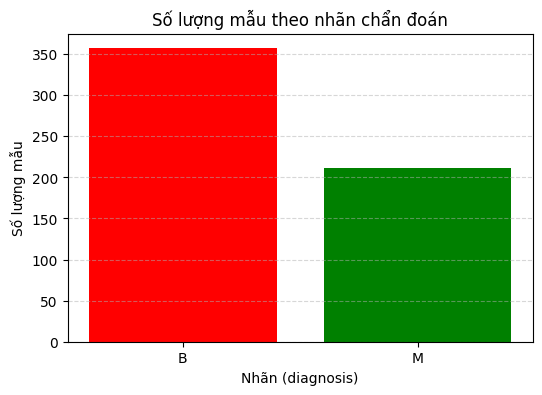

In [9]:
label_counts = y.value_counts()
print(label_counts)
plt.figure(figsize=(6, 4))
plt.bar(label_counts.index, label_counts.values, color=['red', 'green'])
plt.title('Số lượng mẫu theo nhãn chẩn đoán')
plt.xlabel('Nhãn (diagnosis)')
plt.ylabel('Số lượng mẫu')
plt.xticks(ticks=[0, 1], labels=label_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [10]:
X = cancer.drop(['id','diagnosis','Unnamed: 32'],axis=1)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=100)

In [12]:
# check shape of train and test sample
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

In [13]:
y_test.value_counts()

diagnosis
B    102
M     69
Name: count, dtype: int64

## Experiment with many models:
# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
model_logistic = LogisticRegression(max_iter=5000)

In [15]:
# Step 6 : train or fit model
model_logistic.fit(X_train,y_train)

LogisticRegression(max_iter=5000)

In [16]:
model_logistic.intercept_

array([-24.05619596])

In [17]:
model_logistic.coef_

array([[-0.66442902, -0.13990267, -0.06958578, -0.0056466 ,  0.12546184,
         0.14879602,  0.35608522,  0.1899057 ,  0.19734491,  0.0206078 ,
         0.04121735, -0.73697826, -0.17821747,  0.12507701,  0.01456343,
        -0.04293153,  0.03821293,  0.02792308,  0.02678602, -0.00895049,
        -0.2299762 ,  0.41020221,  0.28792063,  0.00560562,  0.23618063,
         0.56711969,  1.10263655,  0.42863376,  0.50685386,  0.08171209]])

In [18]:
# Step 7 : predict model
y_pred = model_logistic.predict(X_test)
y_pred

array(['M', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M',
       'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'M',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B',
       'M', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M',
       'M', 'B', 'B', 'M', 'M', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'B',
       'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'M', 'M', 'B', 'M',
       'M', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B',
       'M', 'B'], dtype=object)

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [20]:
confusion_matrix(y_test,y_pred)

array([[99,  3],
       [ 5, 64]], dtype=int64)

In [21]:
accuracy_score(y_test,y_pred)

0.9532163742690059

In [22]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           B       0.95      0.97      0.96       102
           M       0.96      0.93      0.94        69

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



# Decision Tree

# SVM + GridSearchCV(optimize hypeparameter)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

svc = SVC()
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],  
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy') ## cv for cross-validation
grid_search.fit(X_train, y_train)

# Best result
print("Best parameters:", grid_search.best_params_)
print("Best score on train:", grid_search.best_score_)

# evaluate on test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test accuracy:", test_score)
print("Test confusion matrix:")
print(confusion_matrix(y_test, best_model.predict(X_test)))
print("Test classification report:")
print(classification_report(y_test, best_model.predict(X_test)))


# Random Forest + GridSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Instantiate the model
rf = RandomForestClassifier(random_state=42)

# parameter space
param_grid = {
    'n_estimators': [100, 200, 300],         # nUmber of trees in the forest
    'max_depth': [None, 10, 20, 30],         # depth of the tree
    'min_samples_split': [2, 5, 10],         
    'min_samples_leaf': [1, 2, 4],           
    'bootstrap': [True, False]               # if bootstrap samples when building trees
}


In [ ]:
grid_search_rf = GridSearchCV(estimator=rf, 
                              param_grid=param_grid, 
                              cv=5, 
                              scoring='accuracy',
                              n_jobs=-1)

grid_search_rf.fit(X_train, y_train)


In [ ]:
print("Best parameters:", grid_search_rf.best_params_)
print("Best cross-validation score:", grid_search_rf.best_score_)

# Evaluate on test set
best_rf_model = grid_search_rf.best_estimator_
print("Test accuracy:", best_rf_model.score(X_test, y_test))
print("Test confusion matrix:")
print(confusion_matrix(y_test, best_rf_model.predict(X_test)))
print("Test classification report:")
print(classification_report(y_test, best_rf_model.predict(X_test)))
